# GoogLeNet 이란

**GoogLeNet** 은 2014년 Google 팀이 발표한 이미지 분류용 CNN(합성곱 신경망) 아키텍처로, 그해 **ImageNet 대회(ILSVRC 2014)에서 우승**한 모델입니다. 논문 이름은 "Going Deeper with Convolutions"이고, LeNet(초기 CNN의 대표작)에 대한 오마주로 이름을 GoogLeNet이라 지었습니다.



## 핵심 아이디어: Inception 모듈

GoogLeNet의 가장 큰 특징은 **Inception 모듈**이라는 구조입니다.

일반적인 CNN은 각 층에서 3×3 필터를 쓸지, 5×5를 쓸지, pooling을 쓸지 하나를 골라야 합니다. Inception 모듈은 이걸 **"다 해보고 합치자"** 방식으로 풉니다:

```
        입력
    ┌────┼────┬────────┐
   1x1   1x1  1x1    3x3 pool
    │     │    │        │
    │    3x3  5x5      1x1
    │     │    │        │
    └────→ 채널 방향으로 concat ←────┘
        출력
```

같은 입력에 대해 1×1, 3×3, 5×5 컨볼루션과 풀링을 병렬로 적용한 뒤 결과를 채널 축으로 이어붙입니다. 서로 다른 크기의 특징(작은 디테일 ~ 넓은 문맥)을 동시에 잡아낼 수 있죠. 이때 3×3, 5×5 앞에 **1×1 컨볼루션**을 끼워 넣어 채널 수를 먼저 줄이는데, 이게 연산량을 크게 절약하는 핵심 트릭입니다(이 방식은 "Network in Network" 논문에서 아이디어를 가져왔습니다).

## 다른 특징

- **22층**(파라미터가 있는 층 기준)의 상당히 깊은 네트워크지만, 이런 구조 덕분에 **AlexNet보다 파라미터 수는 훨씬 적습니다**(약 500만 개 vs AlexNet의 6천만 개).
- 마지막에 fully-connected 층 대신 **Global Average Pooling**을 사용해 파라미터를 더 줄였습니다.
- 학습 중 그래디언트 소실(vanishing gradient) 문제를 완화하려고 네트워크 중간에 **보조 분류기(auxiliary classifier)** 를 2개 더 달아서 함께 학습시켰습니다(추론 시엔 제거).
- 입력 크기는 **224×224**, ImageNet의 **1000개 클래스** 를 분류하도록 학습됐습니다
    - 아래 실습 코드에서 `blobFromImage`의 `(224, 224)`와 `classNames`가 1000개인 이유가 바로 이겁니다.

이후 Inception v2, v3, v4로 계속 개선되었고, "여러 크기의 필터를 병렬로 쓴다"는 이 아이디어는 이후 많은 CNN 설계에 영향을 줬습니다.

# GoogLeNet 영상인식

**OpenCV의 DNN(딥러닝) 모듈을 이용한 이미지 분류(image classification)** 

- **사전 학습된 GoogLeNet(Inception v1)** 모델을 OpenCV에 불러와서
- 임의의 사진(`space_shuttle.jpg` 등)을 넣으면
- **ImageNet의 1000개 클래스 중 어떤 물체인지**를 예측하고
- 확률(신뢰도)과 함께 이미지 위에 결과를 표시(`cv2.putText`)하는 흐름을 보여줍니다.

딥러닝 모델을 직접 학습시키는 게 아니라, **이미 학습된(pretrained) 모델을 OpenCV `cv2.dnn` API로 불러와 추론(inference)만 수행** 할수 있습니다

1. `cv2.dnn.readNet(FromONNX)` — 모델 로드
2. `cv2.dnn.blobFromImage` — 입력 영상을 모델이 원하는 형태(크기 224×224, BGR 평균값 빼기 등)로 전처리해서 4차원 blob으로 변환
3. `net.setInput()` / `net.forward()` — 순전파(forward pass)로 추론 실행
4. `np.argmax()`로 가장 확률 높은 클래스 찾기 → 결과 시각화




**🚩OpenCV 5.0으로 넘어오면서 Caffe 모델 로더가 제거된 변화**에 맞춰, 예전 Caffe 형식(`.caffemodel`+`.prototxt`) 대신 **ONNX로 변환된 GoogLeNet**을 쓰도록 코드를 고치는 마이그레이션 이슈도 함께 다뤘습니다.


# ONNX 란

**ONNX (Open Neural Network Exchange)** 는 여러 딥러닝 프레임워크 사이에서 모델을 서로 주고받을 수 있게 만든 **공통 모델 파일 포맷(표준 포맷)** 입니다.

## 왜 필요한가

딥러닝 프레임워크는 여러 개가 있죠 — PyTorch, TensorFlow, Caffe, MXNet, scikit-learn 등. 문제는:

- PyTorch로 학습한 모델은 기본적으로 PyTorch에서만 잘 돌아가고
- TensorFlow로 학습한 모델은 TensorFlow 생태계에 묶이고
- Caffe 모델은 Caffe(또는 Caffe를 지원하던 도구)에서만 쓸 수 있었습니다.

이렇게 되면 "PyTorch로 학습했는데 C++ 서버나 모바일, 임베디드 기기에 배포하고 싶다" 같은 상황에서 매번 변환기를 새로 짜야 하는 문제가 생깁니다.

**ONNX는 이 문제를 풀기 위해 Microsoft와 Facebook(현 Meta)이 주도해서 만든 중간 표현(intermediate representation) 포맷**입니다. 신경망의 구조(레이어, 연산 그래프)와 학습된 가중치를 프레임워크에 종속되지 않는 형태로 저장합니다.

```
PyTorch 모델 ─┐
TensorFlow 모델 ─┼─→ [ONNX 파일 (.onnx)] ─→ OpenCV, ONNX Runtime,
Caffe 모델 ─┘                              TensorRT, 모바일 등에서 실행
```

## GoogLeNet 이슈

- 예전 GoogLeNet은 **Caffe 형식**(`deploy.prototxt` + `bvlc_googlenet.caffemodel`)으로 배포돼 있었는데
- **OpenCV 5.0** 에서 Caffe 로더 자체가 빠져버렸습니다.
- 그런데 ONNX 로더(`readNetFromONNX`)는 계속 남아있고, 오히려 OpenCV 5의 새 추론 엔진이 ONNX를 표준 입력 포맷으로 채택했습니다.
- 그래서 누군가가 이미 Caffe → ONNX로 변환해둔 `googlenet-12.onnx` 파일(ONNX Model Zoo 등에서 배포)을 대신 쓰면 OpenCV 5에서도 문제없이 로드할 수 있는 것이었죠.

## 참고로

- 확장자는 `.onnx`
- 내부적으로는 `protobuf` 기반의 그래프 구조(레이어 연결 관계 + 각 레이어의 op 종류 + weight 텐서)로 저장됩니다.
- 버전이 있습니다(opset version) — `googlenet-12.onnx`의 `12`가 바로 그 opset 버전 번호로, 어떤 연산자 집합을 지원하는지를 나타냅니다.


In [4]:
import sys, os
import numpy as np
import cv2
import matplotlib.pyplot as plt

def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

def plt_imshow(image, axis=True):  # OpenCV 이미지를 matplotlib 으로 출력하기
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis(axis)
    plt.show()       

In [5]:
base_path = r"/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify"

(320, 320, 3)


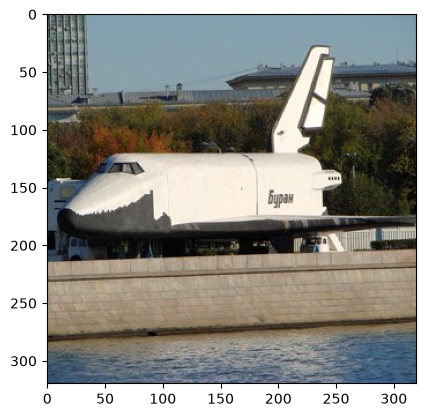

In [6]:
filename = os.path.join(base_path, 'space_shuttle.jpg')
img = cv2.imread(filename)
print(img.shape)
plt_imshow(img)

In [ ]:
# ONNX로 변환된 GoogLeNet 사용
# ONNX Model Zoo (onnx/models 깃허브 저장소: https://github.com/onnx/models)에서 
# vision/classification/inception_and_googlenet/googlenet 경로에 있는 .onnx 파일을 받으면 됩니다.
# https://github.com/onnx/models/tree/main/validated/vision/classification/inception_and_googlenet/googlenet/model

In [8]:
net = cv2.dnn.readNetFromONNX(os.path.join(base_path, 'googlenet-12.onnx'))

if net.empty():
    print('💥Network load failed!')

In [13]:
# deploy.prototxt : Caffe 프레임워크에서 신경망의 "구조(architecture)"만 정의한 설정 파일
#  이 파일은 BVLC (Berkeley Vision and Learning Center)의 Caffe Model Zoo에서 배포된 bvlc_googlenet 모델의 일부

!cat {base_path}/deploy.prototxt

# input_param { shape: { dim: 10 dim: 3 dim: 224 dim: 224 } }
# inner_product_param {
#     num_output: 1000    <- 1000개의 output class

name: "GoogleNet"
layer {
  name: "data"
  type: "Input"
  top: "data"
  input_param { shape: { dim: 10 dim: 3 dim: 224 dim: 224 } }
}
layer {
  name: "conv1/7x7_s2"
  type: "Convolution"
  bottom: "data"
  top: "conv1/7x7_s2"
  param {
    lr_mult: 1
    decay_mult: 1
  }
  param {
    lr_mult: 2
    decay_mult: 0
  }
  convolution_param {
    num_output: 64
    pad: 3
    kernel_size: 7
    stride: 2
    weight_filler {
      type: "xavier"
      std: 0.1
    }
    bias_filler {
      type: "constant"
      value: 0.2
    }
  }
}
layer {
  name: "conv1/relu_7x7"
  type: "ReLU"
  bottom: "conv1/7x7_s2"
  top: "conv1/7x7_s2"
}
layer {
  name: "pool1/3x3_s2"
  type: "Pooling"
  bottom: "conv1/7x7_s2"
  top: "pool1/3x3_s2"
  pooling_param {
    pool: MAX
    kernel_size: 3
    stride: 2
  }
}
layer {
  name: "pool1/norm1"
  type: "LRN"
  bottom: "pool1/3x3_s2"
  top: "pool1/norm1"
  lrn_param {
    local_size: 5
    alpha: 0.0001
    beta: 0.75
  }
}
layer {
  name: "conv2/3x3_reduce"
  

In [15]:
# class 이름 읽어오기

classNames = None
with open(os.path.join(base_path, 'classification_classes_ILSVRC2012.txt'), 'rt') as f:
    classNames = f.read().rstrip('\n').split('\n')
    
print(len(classNames))  # <-- 1000 개의 클래스
classNames    

1000


['tench, Tinca tinca',
 'goldfish, Carassius auratus',
 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 'tiger shark, Galeocerdo cuvieri',
 'hammerhead, hammerhead shark',
 'electric ray, crampfish, numbfish, torpedo',
 'stingray',
 'cock',
 'hen',
 'ostrich, Struthio camelus',
 'brambling, Fringilla montifringilla',
 'goldfinch, Carduelis carduelis',
 'house finch, linnet, Carpodacus mexicanus',
 'junco, snowbird',
 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 'robin, American robin, Turdus migratorius',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel, dipper',
 'kite',
 'bald eagle, American eagle, Haliaeetus leucocephalus',
 'vulture',
 'great grey owl, great gray owl, Strix nebulosa',
 'European fire salamander, Salamandra salamandra',
 'common newt, Triturus vulgaris',
 'eft',
 'spotted salamander, Ambystoma maculatum',
 'axolotl, mud puppy, Ambystoma mexicanum',
 'bullfrog, Rana catesbeiana',
 'tree frog, tree-f

In [21]:
# 모델에 입력할 영상은 blob 객체로 만들어서 입력해야 함.   (※ blob: binary large object)

inputBlob = cv2.dnn.blobFromImage(
    img,   # BGR 채널을 갖는 영상
    1,     # scale factor
    (224, 224),  # 이를 224 x 224 size 로 스케일링 (모델의 입력 사이즈!)
    (104, 117, 123),  # BGR 채널의 평균값을 지정.
                    # GoogLeNet 모델 학습시 사용한 평균값 (전처리)
                    # 이 값을 제대로 안주면 정확한 추론 안된다.
)

# blobFromImage() 의 리턴값이 blob  ← (blob 은 걍 다차원 행렬 이라 보시면 됨.  
# 정확히는 4차원 행렬 (N, C, H, W)   (Number, Channel, Height, Width)
# 이렇게 리턴된 blob 이 다음의 setInput() 의 입력으로 전달된다.

In [22]:
print(inputBlob.shape)
inputBlob

# ↓ BGR 값이 rescaling 된것이 보인다.

(1, 3, 224, 224)


array([[[[-11., -21.,  45., ...,  62.,  62.,  61.],
         [-18., -23.,  42., ...,  63.,  62.,  62.],
         [-26., -33.,  43., ...,  63.,  63.,  62.],
         ...,
         [ 15.,  14.,  14., ...,  16.,  11.,  10.],
         [  9.,  10.,  13., ...,   8.,   7.,  13.],
         [  5.,   1.,   5., ...,   4.,   2.,  -3.]],

        [[-23., -33.,  33., ...,  33.,  33.,  32.],
         [-31., -36.,  28., ...,  34.,  33.,  33.],
         [-40., -47.,  29., ...,  34.,  34.,  33.],
         ...,
         [-32., -33., -31., ..., -29., -34., -35.],
         [-39., -37., -34., ..., -38., -39., -32.],
         [-45., -47., -42., ..., -43., -45., -50.]],

        [[-38., -48.,  17., ...,  -2.,  -2.,  -3.],
         [-47., -52.,  13., ...,  -1.,  -2.,  -2.],
         [-57., -63.,  13., ...,  -1.,  -1.,  -2.],
         ...,
         [-67., -68., -66., ..., -63., -69., -70.],
         [-73., -72., -69., ..., -73., -74., -68.],
         [-79., -82., -77., ..., -79., -81., -86.]]]],
      shape=(1,

In [23]:
# 네트워크의 입력 설정
net.setInput(inputBlob)

In [24]:
# 추론 inference  (예측)
pred = net.forward()  

print(pred.shape) # (1, 1000)
print(np.sum(pred))  # 확률값 합하면 1.  여기서 가장 큰 확률 찾으면 된다

(1, 1000)
1.0000001


In [25]:
out = pred.flatten()
classId = np.argmax(out)
confidence = out[classId]  # 가장 큰 확률값

print(classId, confidence, classNames[classId])

812 0.99993205 space shuttle


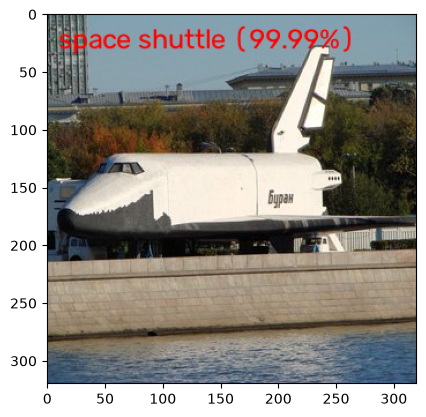

In [26]:
text = '%s (%4.2f%%)' % (classNames[classId], confidence * 100)
cv2.putText(img, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 1, cv2.LINE_AA)

plt_imshow(img)

# 함수로 만들기

In [28]:
def classify(filename):
    img = cv2.imread(filename)
    
    if img is None:
        filename = os.path.join(base_path, sys.argv[1])
        exit()
    
    # Load network
    
    net = cv2.dnn.readNetFromONNX(os.path.join(base_path, 'googlenet-12.onnx'))
    
    if net.empty():
        print('Network load failed!')
        exit()
    
    # Load class names
    
    classNames = None
    with open(os.path.join(base_path, 'classification_classes_ILSVRC2012.txt'), 'rt') as f:
        classNames = f.read().rstrip('\n').split('\n')
    
    # Inference
    
    inputBlob = cv2.dnn.blobFromImage(img, 1, (224, 224), (104, 117, 123))
    net.setInput(inputBlob)
    prob = net.forward()
    
    # Check results & Display
    
    out = prob.flatten()
    classId = np.argmax(out)
    confidence = out[classId]
    
    text = '%s (%4.2f%%)' % (classNames[classId], confidence * 100)
    cv2.putText(img, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 1, cv2.LINE_AA)    

    plt_imshow(img)

In [29]:
import glob
img_list = glob.glob(os.path.join(base_path, '*.jpg'))
img_list

['/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify/space_shuttle.jpg',
 '/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify/pineapple.jpg',
 '/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify/beagle.jpg',
 '/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify/cup.jpg',
 '/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/classify/scooter.jpg']

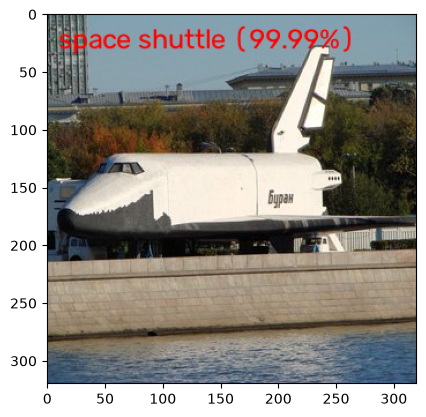

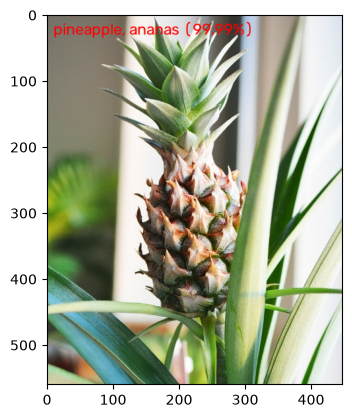

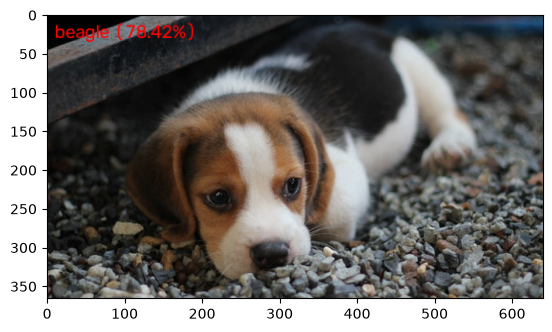

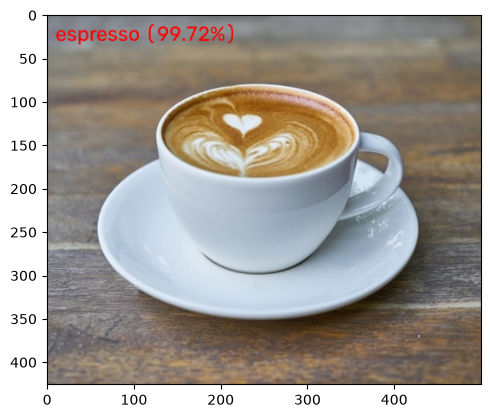

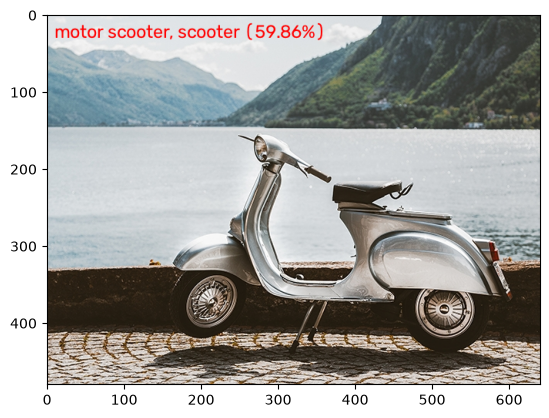

In [30]:
for img in img_list:
    classify(img)